In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('student_prediction_dataset_realistic.csv')

In [ ]:
def make_weekly_dataset(df):
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    # week bucket
    df["week"] = df["timestamp"].dt.to_period("W").apply(lambda r: r.start_time)

    weekly = (
        df.groupby(["student_id", "week"])
        .agg(
            week_avg_score=("score", "mean"),
            week_std_score=("score", "std"),
            week_avg_difficulty=("difficulty", "mean"),
            week_total_time_spent=("time_spent", "sum"),
            week_avg_wait=("wait_time", "mean"),
            week_resource_score=("resource_score", "mean"),
            interactions=("score", "count"),
        )
        .reset_index()
        .sort_values(["student_id", "week"])
    )

    weekly["week_std_score"] = weekly["week_std_score"].fillna(0)

    return weekly

In [ ]:
def add_future_targets(weekly_df, horizon=4):
    weekly_df = weekly_df.copy()
    g = weekly_df.groupby("student_id")

    for h in range(1, horizon + 1):
        weekly_df[f"y_week_{h}"] = g["week_avg_score"].shift(-h)

    return weekly_df

In [ ]:
FEATURE_COLS = [
    "week_avg_score",
    "week_std_score",
    "week_avg_difficulty",
    "week_total_time_spent",
    "week_avg_wait",
    "week_resource_score",
    "interactions",
]

TARGET_COLS = ["y_week_1", "y_week_2", "y_week_3", "y_week_4"]


In [ ]:
weekly_df = make_weekly_dataset(df)
weekly_df = add_future_targets(weekly_df, horizon=4)

weekly_df = weekly_df.dropna(
    subset=TARGET_COLS
).reset_index(drop=True)

# Ensure all feature and target columns are explicitly numeric (float32)
all_numeric_cols = FEATURE_COLS + TARGET_COLS
weekly_df[all_numeric_cols] = weekly_df[all_numeric_cols].astype(np.float32)

In [ ]:
import torch
from torch.utils.data import Dataset

class WeeklyForecastDataset(Dataset):
    def __init__(self, df, seq_len=6):
        self.df = df
        self.seq_len = seq_len
        self.samples = []

        for sid, g in df.groupby("student_id"):
            g = g.sort_values("week")
            if len(g) < seq_len:
                continue

            for i in range(seq_len, len(g)):
                x = g.iloc[i - seq_len:i][FEATURE_COLS].values.astype(np.float32)
                y = g.iloc[i][TARGET_COLS].values.astype(np.float32)
                self.samples.append((x, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )

In [ ]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 47.9 MB/s eta 0:00:00


In [ ]:
import torch.nn as nn
import pytorch_lightning as pl

class WeeklyForecastModel(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim=64, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            num_layers=2,
            dropout=0.2,
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 4),  # predict 4 future weeks
        )

        self.lr = lr

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        h = h_n[-1]
        return self.head(h)

    def training_step(self, batch, _):
        x, y = batch
        y_hat = self(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        y_hat = self(x)
        loss = nn.functional.mse_loss(y_hat, y)
        self.log("val_loss", loss, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)


In [ ]:
import numpy as np
from torch.utils.data import DataLoader
from sklearn.preprocessing import RobustScaler

student_ids = weekly_df["student_id"].unique()
rng = np.random.default_rng(42)

train_ids = rng.choice(student_ids, size=int(0.8 * len(student_ids)), replace=False)

train_df = weekly_df[weekly_df["student_id"].isin(train_ids)]
val_df = weekly_df[~weekly_df["student_id"].isin(train_ids)]

train_ds = WeeklyForecastDataset(train_df)
val_ds = WeeklyForecastDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

In [ ]:
model = WeeklyForecastModel(input_dim=len(FEATURE_COLS))

from pytorch_lightning.loggers import CSVLogger

logger = CSVLogger("logs", name="student_transformer_model")

trainer = pl.Trainer(
    max_epochs=40,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    precision=32,  # switch to 16 later
    logger=logger,
)

trainer.fit(model, train_loader, val_loader)


INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


┏━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm │ LSTM       │ 52.0 K │ train │     0 │
│ 1 │ head │ Sequential │  4.4 K │ train │     0 │
└───┴──────┴────────────┴────────┴───────┴───────┘

Trainable params: 56.4 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 56.4 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:317: The number of training batches 
(10) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if
you want to see logs for the training epoch.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=40` reached.


In [ ]:
import pandas as pd
import os

# Define the path to the logs directory
log_dir = "logs/student_transformer_model"

# Find the latest version directory
versions = [d for d in os.listdir(log_dir) if d.startswith('version_')]
if not versions:
    raise FileNotFoundError(f"No version directories found in {log_dir}")

latest_version = sorted(versions, key=lambda x: int(x.split('_')[1]))[-1]
metrics_path = os.path.join(log_dir, latest_version, "metrics.csv")

# Load the metrics CSV
if not os.path.exists(metrics_path):
    raise FileNotFoundError(f"Metrics file not found at {metrics_path}")

metrics_df = pd.read_csv(metrics_path)

print(f"Metrics loaded from: {metrics_path}")
display(metrics_df.head())

Metrics loaded from: logs/student_transformer_model/version_0/metrics.csv


,epoch,step,train_loss,val_loss
0,0,9,NaN,3989.591309
1,1,19,NaN,3836.298584
2,2,29,NaN,3547.004883
3,3,39,NaN,3155.318359
4,4,49,2724.324707,NaN


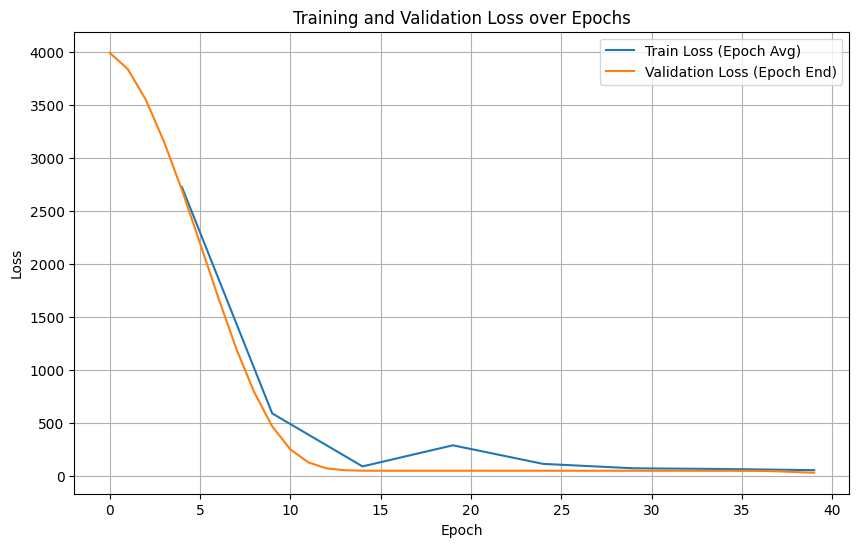

In [ ]:
import matplotlib.pyplot as plt

# Ensure epoch is treated as an integer for grouping
metrics_df['epoch'] = metrics_df['epoch'].ffill().astype(int)

# Aggregate training loss: take the mean train_loss for each epoch
train_loss_per_epoch = metrics_df.dropna(subset=['train_loss']).groupby('epoch')['train_loss'].mean().reset_index()

# Aggregate validation loss: take the last recorded val_loss for each epoch
# This handles NaNs and ensures one point per epoch
val_loss_per_epoch = metrics_df.dropna(subset=['val_loss']).groupby('epoch')['val_loss'].last().reset_index()

plt.figure(figsize=(10, 6))
plt.plot(train_loss_per_epoch['epoch'], train_loss_per_epoch['train_loss'], label='Train Loss (Epoch Avg)')
plt.plot(val_loss_per_epoch['epoch'], val_loss_per_epoch['val_loss'], label='Validation Loss (Epoch End)')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import torch
import joblib

MODEL_PATH = '/content/logs/student_transformer_model/version_0/checkpoints/weekly_model.ckpt'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = WeeklyForecastModel.load_from_checkpoint(
    MODEL_PATH,
    input_dim=len(FEATURE_COLS)
)
model.to(device)
model.eval()

WeeklyForecastModel(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=4, bias=True)
  )
)

In [ ]:
def prepare_weekly_input(student_weekly_df, feature_cols, seq_len):
    """
    student_weekly_df: dataframe with weekly rows for ONE student
    """
    student_weekly_df = student_weekly_df.sort_values("week")

    if len(student_weekly_df) < seq_len:
        raise ValueError("Not enough weekly history for inference")

    x = student_weekly_df.iloc[-seq_len:][feature_cols].values    # SAME scaler as training
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # [1, seq_len, features]
    return x


In [ ]:
def prepare_weekly_input(student_weekly_df, feature_cols, seq_len):
    """
    student_weekly_df: dataframe with weekly rows for ONE student
    """
    student_weekly_df = student_weekly_df.sort_values("week")

    if len(student_weekly_df) < seq_len:
        raise ValueError("Not enough weekly history for inference")

    x = student_weekly_df.iloc[-seq_len:][feature_cols].values       # SAME scaler as training
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # [1, seq_len, features]
    return x


In [ ]:
student_id_to_predict = val_df['student_id'].iloc[0]
student_df = val_df[val_df['student_id'] == student_id_to_predict].copy()

with torch.no_grad():
    x = prepare_weekly_input(
        student_weekly_df=student_df,
        feature_cols=FEATURE_COLS,
        seq_len=6,
    ).to(device)

    y_pred = model(x)   # shape: [1, 4]

In [ ]:
future_scores = y_pred.squeeze(0).cpu().numpy()

forecast = {
    "week_plus_1": float(future_scores[0]),
    "week_plus_2": float(future_scores[1]),
    "week_plus_3": float(future_scores[2]),
    "week_plus_4": float(future_scores[3]),
}

print(forecast)

{'week_plus_1': 62.647830963134766, 'week_plus_2': 62.39740753173828, 'week_plus_3': 62.32696533203125, 'week_plus_4': 62.13145446777344}


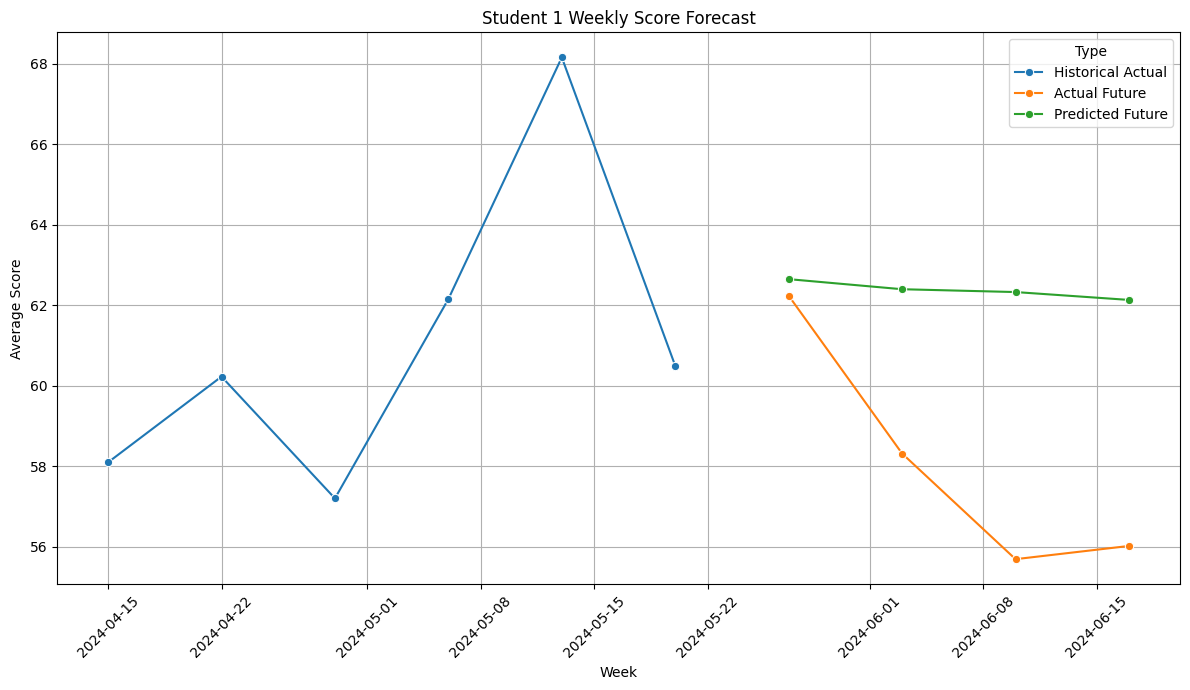

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assume seq_len = 6 as defined in WeeklyForecastDataset
seq_len = 6

# Get the historical data used as input for the prediction
historical_input_df = student_df.iloc[-seq_len:].copy()

# Determine the start week of the forecast
last_historical_week_date = historical_input_df['week'].iloc[-1]

# Generate future weeks for the forecast
forecast_weeks = [last_historical_week_date + pd.Timedelta(weeks=i) for i in range(1, len(TARGET_COLS) + 1)]

# Extract actual future scores from the last row of student_df
actual_future_scores = student_df.iloc[-1][TARGET_COLS].values

# Create DataFrame for actual historical data (input to model)
plot_df_historical = historical_input_df[['week', 'week_avg_score']].copy()
plot_df_historical['Type'] = 'Historical Actual'

# Create DataFrame for actual future data (ground truth for prediction horizon)
plot_df_actual_future = pd.DataFrame({
    'week': forecast_weeks,
    'week_avg_score': actual_future_scores,
    'Type': 'Actual Future'
})

# Create DataFrame for predicted future data
predicted_future_scores = list(forecast.values())
plot_df_predicted_future = pd.DataFrame({
    'week': forecast_weeks,
    'week_avg_score': predicted_future_scores,
    'Type': 'Predicted Future'
})

# Combine all DataFrames for plotting
combined_plot_df = pd.concat([plot_df_historical, plot_df_actual_future, plot_df_predicted_future])

# Plotting
plt.figure(figsize=(12, 7))
sns.lineplot(data=combined_plot_df, x='week', y='week_avg_score', hue='Type', marker='o')
plt.title(f'Student {student_id_to_predict} Weekly Score Forecast')
plt.xlabel('Week')
plt.ylabel('Average Score')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
def make_weekly_dataset(df):
    df = df.copy()
    df["week"] = df["timestamp"].dt.to_period("W").apply(lambda r: r.start_time)

    weekly = (
        df.groupby(["student_id", "week"])
        .agg(
            week_avg_score=("score", "mean"),
            week_std_score=("score", "std"),
            week_avg_difficulty=("difficulty", "mean"),
            week_total_time_spent=("time_spent", "sum"),
            week_avg_wait=("wait_time", "mean"),
            week_resource_score=("resource_score", "mean"),
            interactions=("score", "count"),
        )
        .reset_index()
        .sort_values(["student_id", "week"])
    )

    weekly["week_std_score"] = weekly["week_std_score"].fillna(0)
    return weekly

In [ ]:
weekly_df = make_weekly_dataset(df)

In [ ]:
FEATURE_COLS = [
    "week_avg_score",
    "week_std_score",
    "week_avg_difficulty",
    "week_total_time_spent",
    "week_avg_wait",
    "week_resource_score",
    "interactions",
]

In [ ]:
def build_sequence_json(weekly_df, student_id, seq_len=6):
    student_df = (
        weekly_df[weekly_df["student_id"] == student_id]
        .sort_values("week")
    )

    if len(student_df) < seq_len:
        raise ValueError("Not enough weekly history")

    sequence = (
        student_df
        .iloc[-seq_len:][FEATURE_COLS]
        .astype("float32")
        .values
        .tolist()
    )

    return {"sequence": sequence}


In [ ]:
student_id = weekly_df["student_id"].iloc[0]  # choose any student

payload = build_sequence_json(
    weekly_df=weekly_df,
    student_id=student_id,
    seq_len=6
)

import json

json.dump(payload, open("payload_future.json", "w"))
